In [2]:
import pandas as pd

In [3]:
df=pd.read_csv('/content/heart.csv')

In [4]:
pd.set_option('display.max_columns',None)

In [5]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [6]:
correlation_matrix = df.corr()
# What is the correlation matrix of all numerical variables?

In [7]:
print(correlation_matrix)

               age       sex        cp  trestbps      chol       fbs  \
age       1.000000 -0.103240 -0.071966  0.271121  0.219823  0.121243   
sex      -0.103240  1.000000 -0.041119 -0.078974 -0.198258  0.027200   
cp       -0.071966 -0.041119  1.000000  0.038177 -0.081641  0.079294   
trestbps  0.271121 -0.078974  0.038177  1.000000  0.127977  0.181767   
chol      0.219823 -0.198258 -0.081641  0.127977  1.000000  0.026917   
fbs       0.121243  0.027200  0.079294  0.181767  0.026917  1.000000   
restecg  -0.132696 -0.055117  0.043581 -0.123794 -0.147410 -0.104051   
thalach  -0.390227 -0.049365  0.306839 -0.039264 -0.021772 -0.008866   
exang     0.088163  0.139157 -0.401513  0.061197  0.067382  0.049261   
oldpeak   0.208137  0.084687 -0.174733  0.187434  0.064880  0.010859   
slope    -0.169105 -0.026666  0.131633 -0.120445 -0.014248 -0.061902   
ca        0.271551  0.111729 -0.176206  0.104554  0.074259  0.137156   
thal      0.072297  0.198424 -0.163341  0.059276  0.100244 -0.04

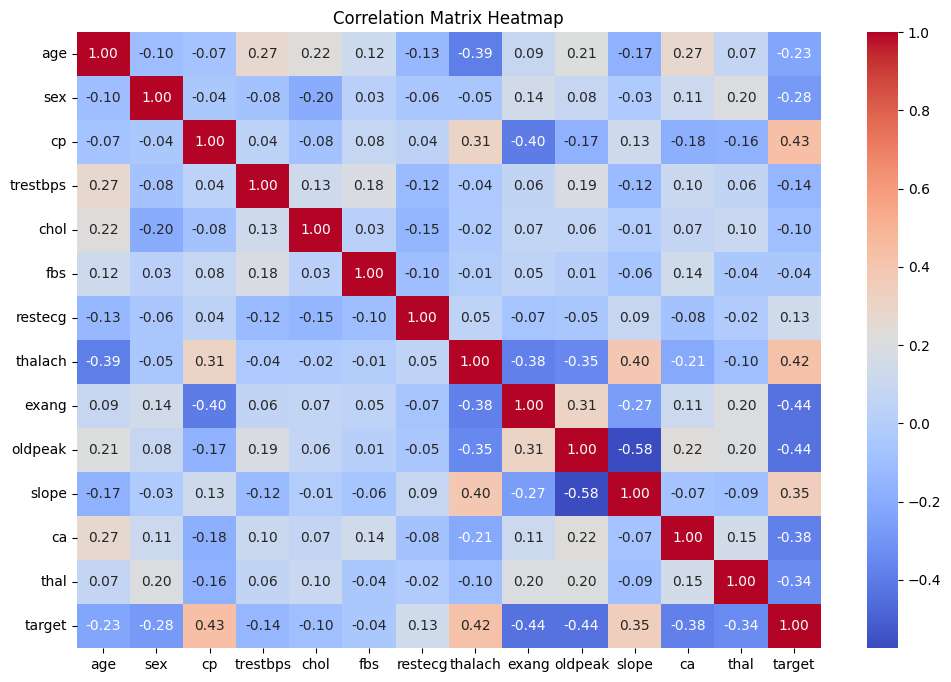

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()
# Heatmap of Correlation Matrix


In [9]:
from scipy.stats import ttest_ind
t_stat, p_val = ttest_ind(df[df['target'] == 1]['chol'], df[df['target'] == 0]['chol'])
# Is there a significant difference in cholesterol levels between patients with and without heart disease?

In [10]:
print("t-statistic:", t_stat)
print("p-value:", p_val)
# A two-sample t-test compares cholesterol means between patients with and without heart disease. A p-value < 0.05 indicates a statistically significant difference, suggesting cholesterol levels are linked to heart disease.

t-statistic: -3.213433097179175
p-value: 0.0013525712504626976


In [12]:
from scipy.stats import chi2_contingency
contingency = pd.crosstab(df['sex'], df['target'])
chi2_stat, p_val, dof, expected = chi2_contingency(contingency)
print("Chi-square statistic:", chi2_stat)
print("p-value:", p_val)
# Is there a significant association between sex and heart disease?
# A Chi-square test evaluates whether the occurrence of heart disease differs significantly between males and females. A very small p-value confirms a strong relationship between sex and heart disease.

Chi-square statistic: 78.86305133922973
p-value: 6.656820681726434e-19


In [13]:
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(df['age'], df['thalach'])
print("Slope:", slope)
print("p-value:", p_value)
print("R-value (correlation coefficient):", r_value)
# What is the relationship between age and maximum heart rate?
# A negative slope indicates that maximum heart rate decreases with age. The highly significant p-value suggests this trend is statistically meaningful.


Slope: -0.9895468570307404
p-value: 1.273826677209368e-38
R-value (correlation coefficient): -0.39022707503159343


In [14]:
from scipy.stats import f_oneway
groups = [group['target'].values for name, group in df.groupby('cp')]
f_stat, p_val = f_oneway(*groups)
print("F-statistic:", f_stat)
print("p-value:", p_val)
# Does chest pain type affect heart disease diagnosis?
# ANOVA shows a significant difference in heart disease presence across different chest pain types. This confirms chest pain is a strong predictor.

F-statistic: 128.52868776274846
p-value: 1.246261315509126e-70


In [15]:
from scipy.stats import pearsonr
corr_val, p_val = pearsonr(df['trestbps'], df['chol'])
print("Correlation coefficient:", corr_val)
print("p-value:", p_val)
# Is there a correlation between resting blood pressure and cholesterol levels?

Correlation coefficient: 0.1279774276376492
p-value: 3.9705771891531236e-05


In [16]:
groups = [group['target'].values for name, group in df.groupby('ca')]
f_stat, p_val = f_oneway(*groups)
print("F-statistic:", f_stat)
print("p-value:", p_val)
# Does the number of major vessels differ between patients with and without heart disease?

F-statistic: 85.46191995289838
p-value: 1.2336391503762187e-62


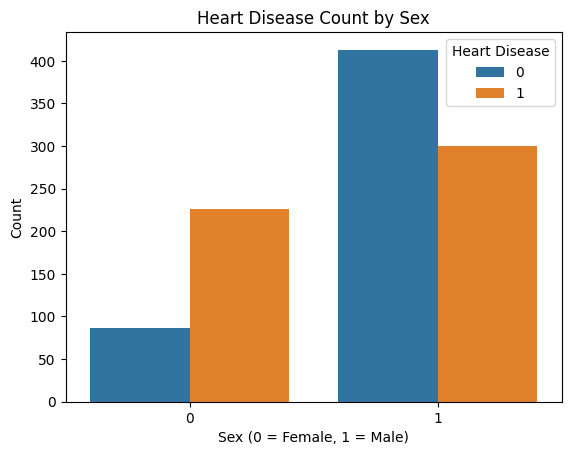

In [17]:
sns.countplot(x='sex', hue='target', data=df)
plt.title('Heart Disease Count by Sex')
plt.xlabel('Sex (0 = Female, 1 = Male)')
plt.ylabel('Count')
plt.legend(title='Heart Disease')
plt.show()
# Heart Disease Count by Sex

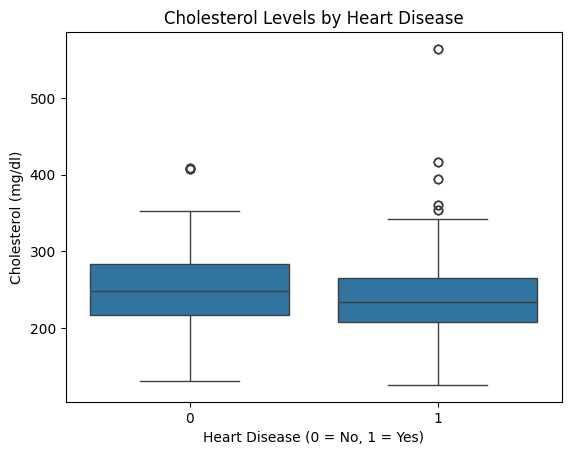

In [18]:
sns.boxplot(x='target', y='chol', data=df)
plt.title('Cholesterol Levels by Heart Disease')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Cholesterol (mg/dl)')
plt.show()
# Boxplot of Cholesterol Levels by Heart Disease

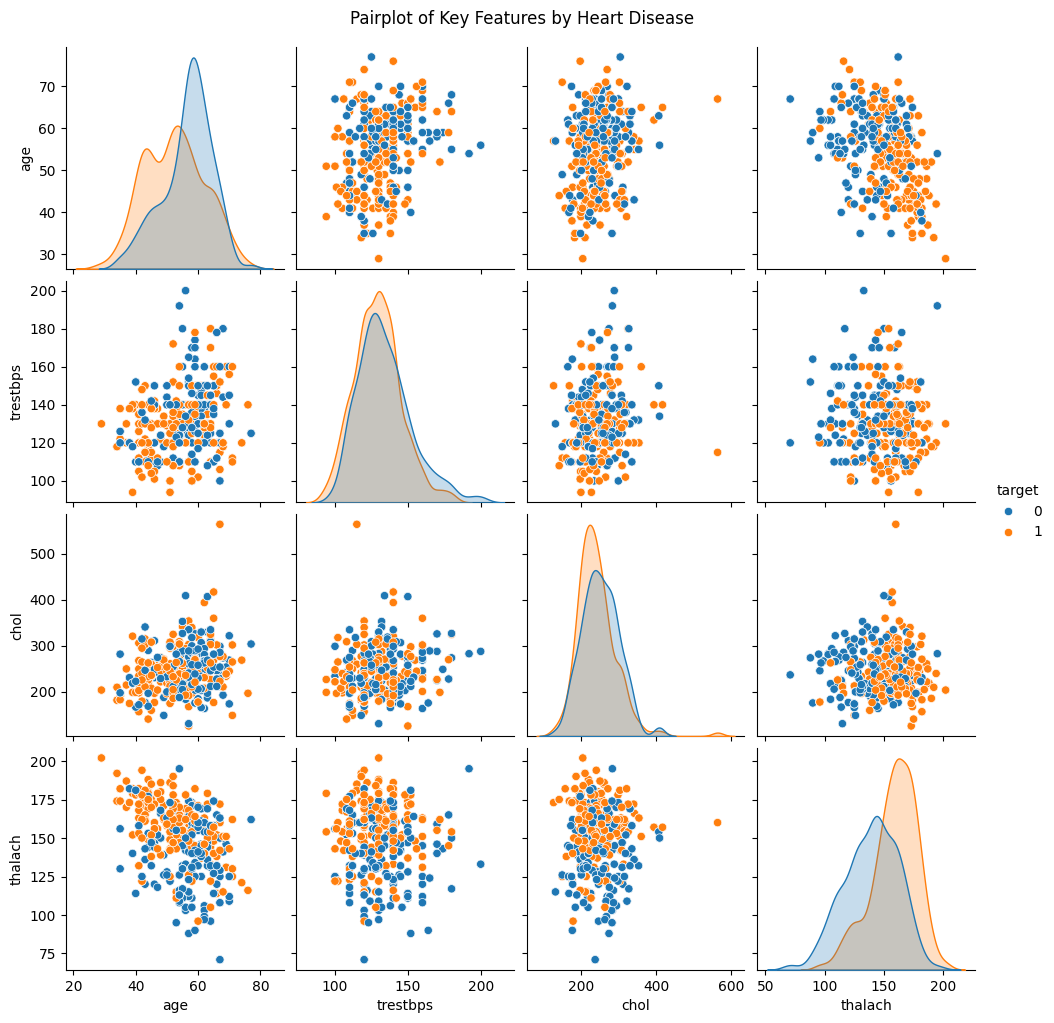

In [19]:
key_features = ['age', 'trestbps', 'chol', 'thalach', 'target']
sns.pairplot(df[key_features], hue='target')
plt.suptitle("Pairplot of Key Features by Heart Disease", y=1.02)
plt.show()
# Pairplot of Key Features

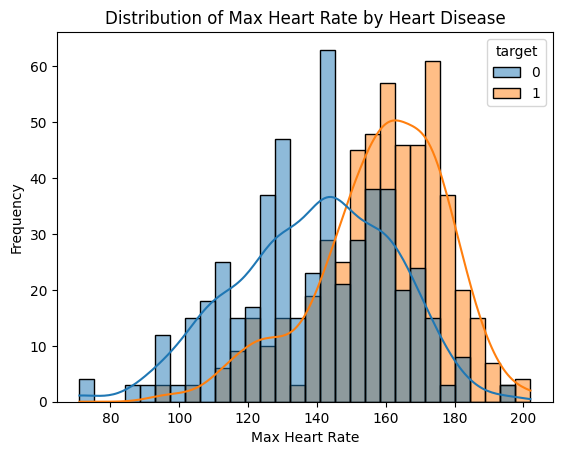

In [20]:
sns.histplot(data=df, x='thalach', hue='target', kde=True, bins=30)
plt.title('Distribution of Max Heart Rate by Heart Disease')
plt.xlabel('Max Heart Rate')
plt.ylabel('Frequency')
plt.show()
# Distribution of Max Heart Rate